## Recitation 4: Finite Difference Methods

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa

from scipy import sparse
from scipy.linalg import solve_banded
from scipy.integrate import solve_ivp
from scipy.sparse.linalg import spsolve, expm_multiply, splu

from matplotlib.animation import FuncAnimation

%matplotlib inline

### Problem 1: 1D Poisson Equation

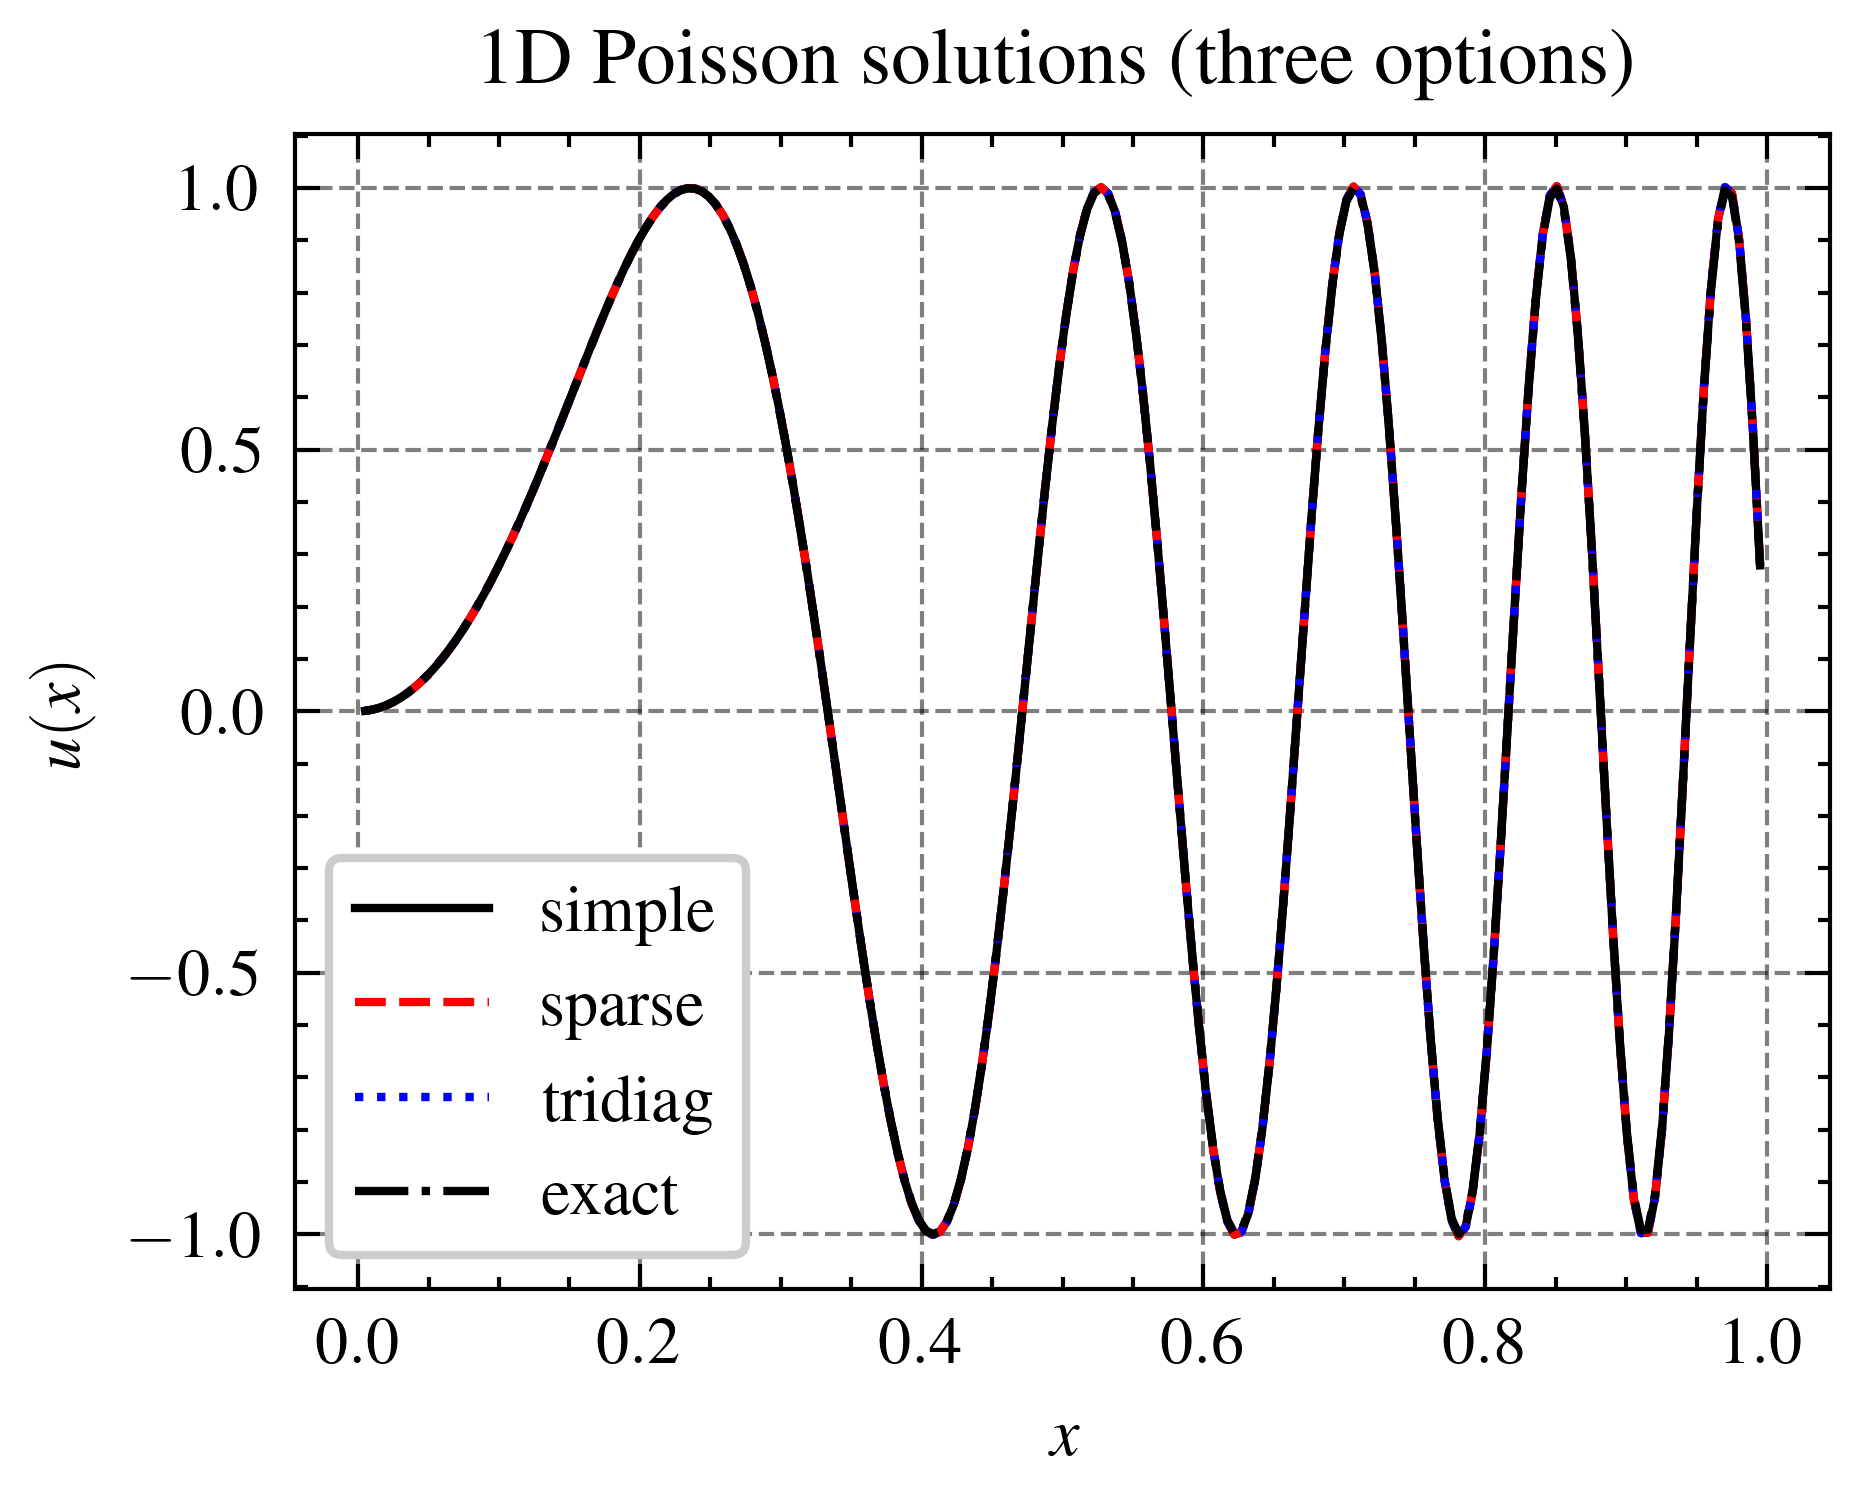

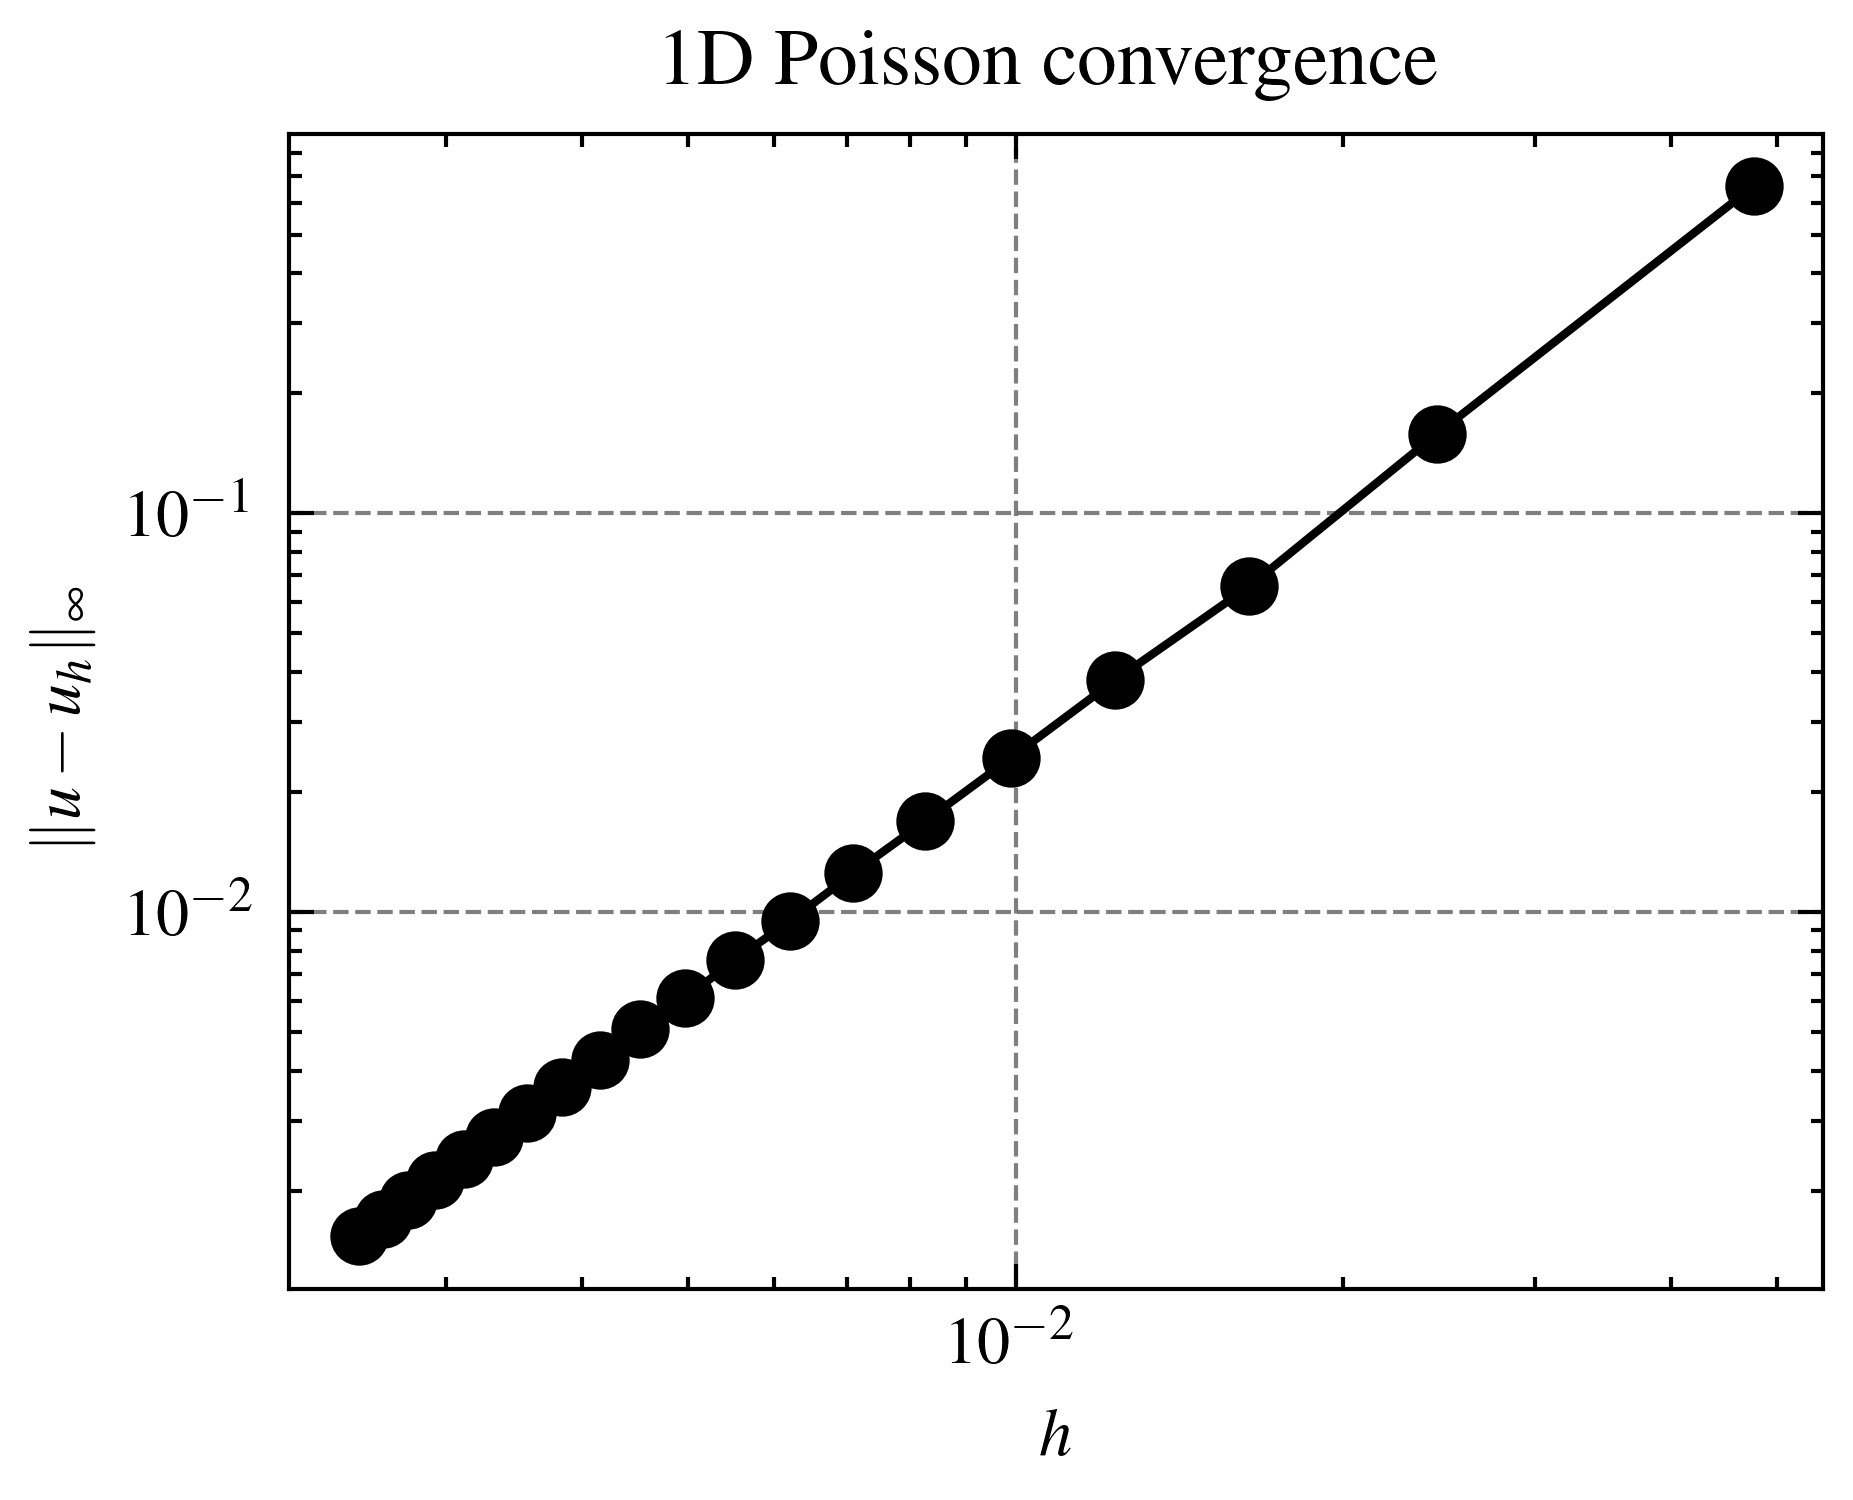

In [2]:
def rhs_f(x):
    return (18 * np.pi * x) ** 2 * np.sin(9 * np.pi * x**2) - 18 * np.pi * np.cos(
        9 * np.pi * x**2
    )


def exact_u(x):
    return np.sin(9 * np.pi * x**2)


def option_simple(n):
    h = 1.0 / (n + 1)
    x = np.linspace(h, 1 - h, n)
    A = np.zeros((n, n))
    for i in range(n):
        A[i, i] = 2
        if i > 0:
            A[i, i - 1] = -1
        if i < n - 1:
            A[i, i + 1] = -1
    f = rhs_f(x) * h**2
    u = np.linalg.solve(A, f)
    return x, u


def option_sparse(n):
    h = 1.0 / (n + 1)
    x = np.linspace(h, 1 - h, n)
    diagonals = [2 * np.ones(n), -1 * np.ones(n - 1), -1 * np.ones(n - 1)]
    A = sparse.diags(diagonals, [0, -1, 1], format="csc")
    f = rhs_f(x) * h**2
    u = spsolve(A, f)
    return x, u


def option_tridiag(n):
    # solve using banded solver: (lower, main, upper)
    h = 1.0 / (n + 1)
    x = np.linspace(h, 1 - h, n)
    lower = -1.0 * np.ones(n - 1)
    main = 2.0 * np.ones(n)
    upper = -1.0 * np.ones(n - 1)
    # solve_banded expects (l,u) bands with shape (l+u+1, n)
    ab = np.zeros((3, n))
    ab[0, 1:] = upper
    ab[1, :] = main
    ab[2, :-1] = lower
    f = rhs_f(x) * h**2
    u = solve_banded((1, 1), ab, f)
    return x, u


n = 200
x, u1 = option_simple(n)
_, u2 = option_sparse(n)
_, u3 = option_tridiag(n)
utrue = exact_u(x)

plt.style.use(["science", "ieee", "grid"])
plt.plot(x, u1, label="simple")
plt.plot(x, u2, "--", label="sparse")
plt.plot(x, u3, ":", label="tridiag")
plt.plot(x, utrue, "k-.", label="exact")
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$u(x)$")
plt.title("1D Poisson solutions (three options)")
plt.show()

ns = np.arange(20, 401, 20)
err = []
h = []
for nn in ns:
    xx, uu = option_sparse(int(nn))
    err.append(np.max(np.abs(uu - exact_u(xx))))
    h.append(1.0 / (nn + 1))
plt.style.use(["science", "ieee", "grid"])
plt.figure()
plt.plot(h, err, "o-")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("$h$")
plt.ylabel("$\\|u - u_h\\|_{\\infty}$")
plt.title("1D Poisson convergence")
plt.show()

### Problem 2: Spring Mass System

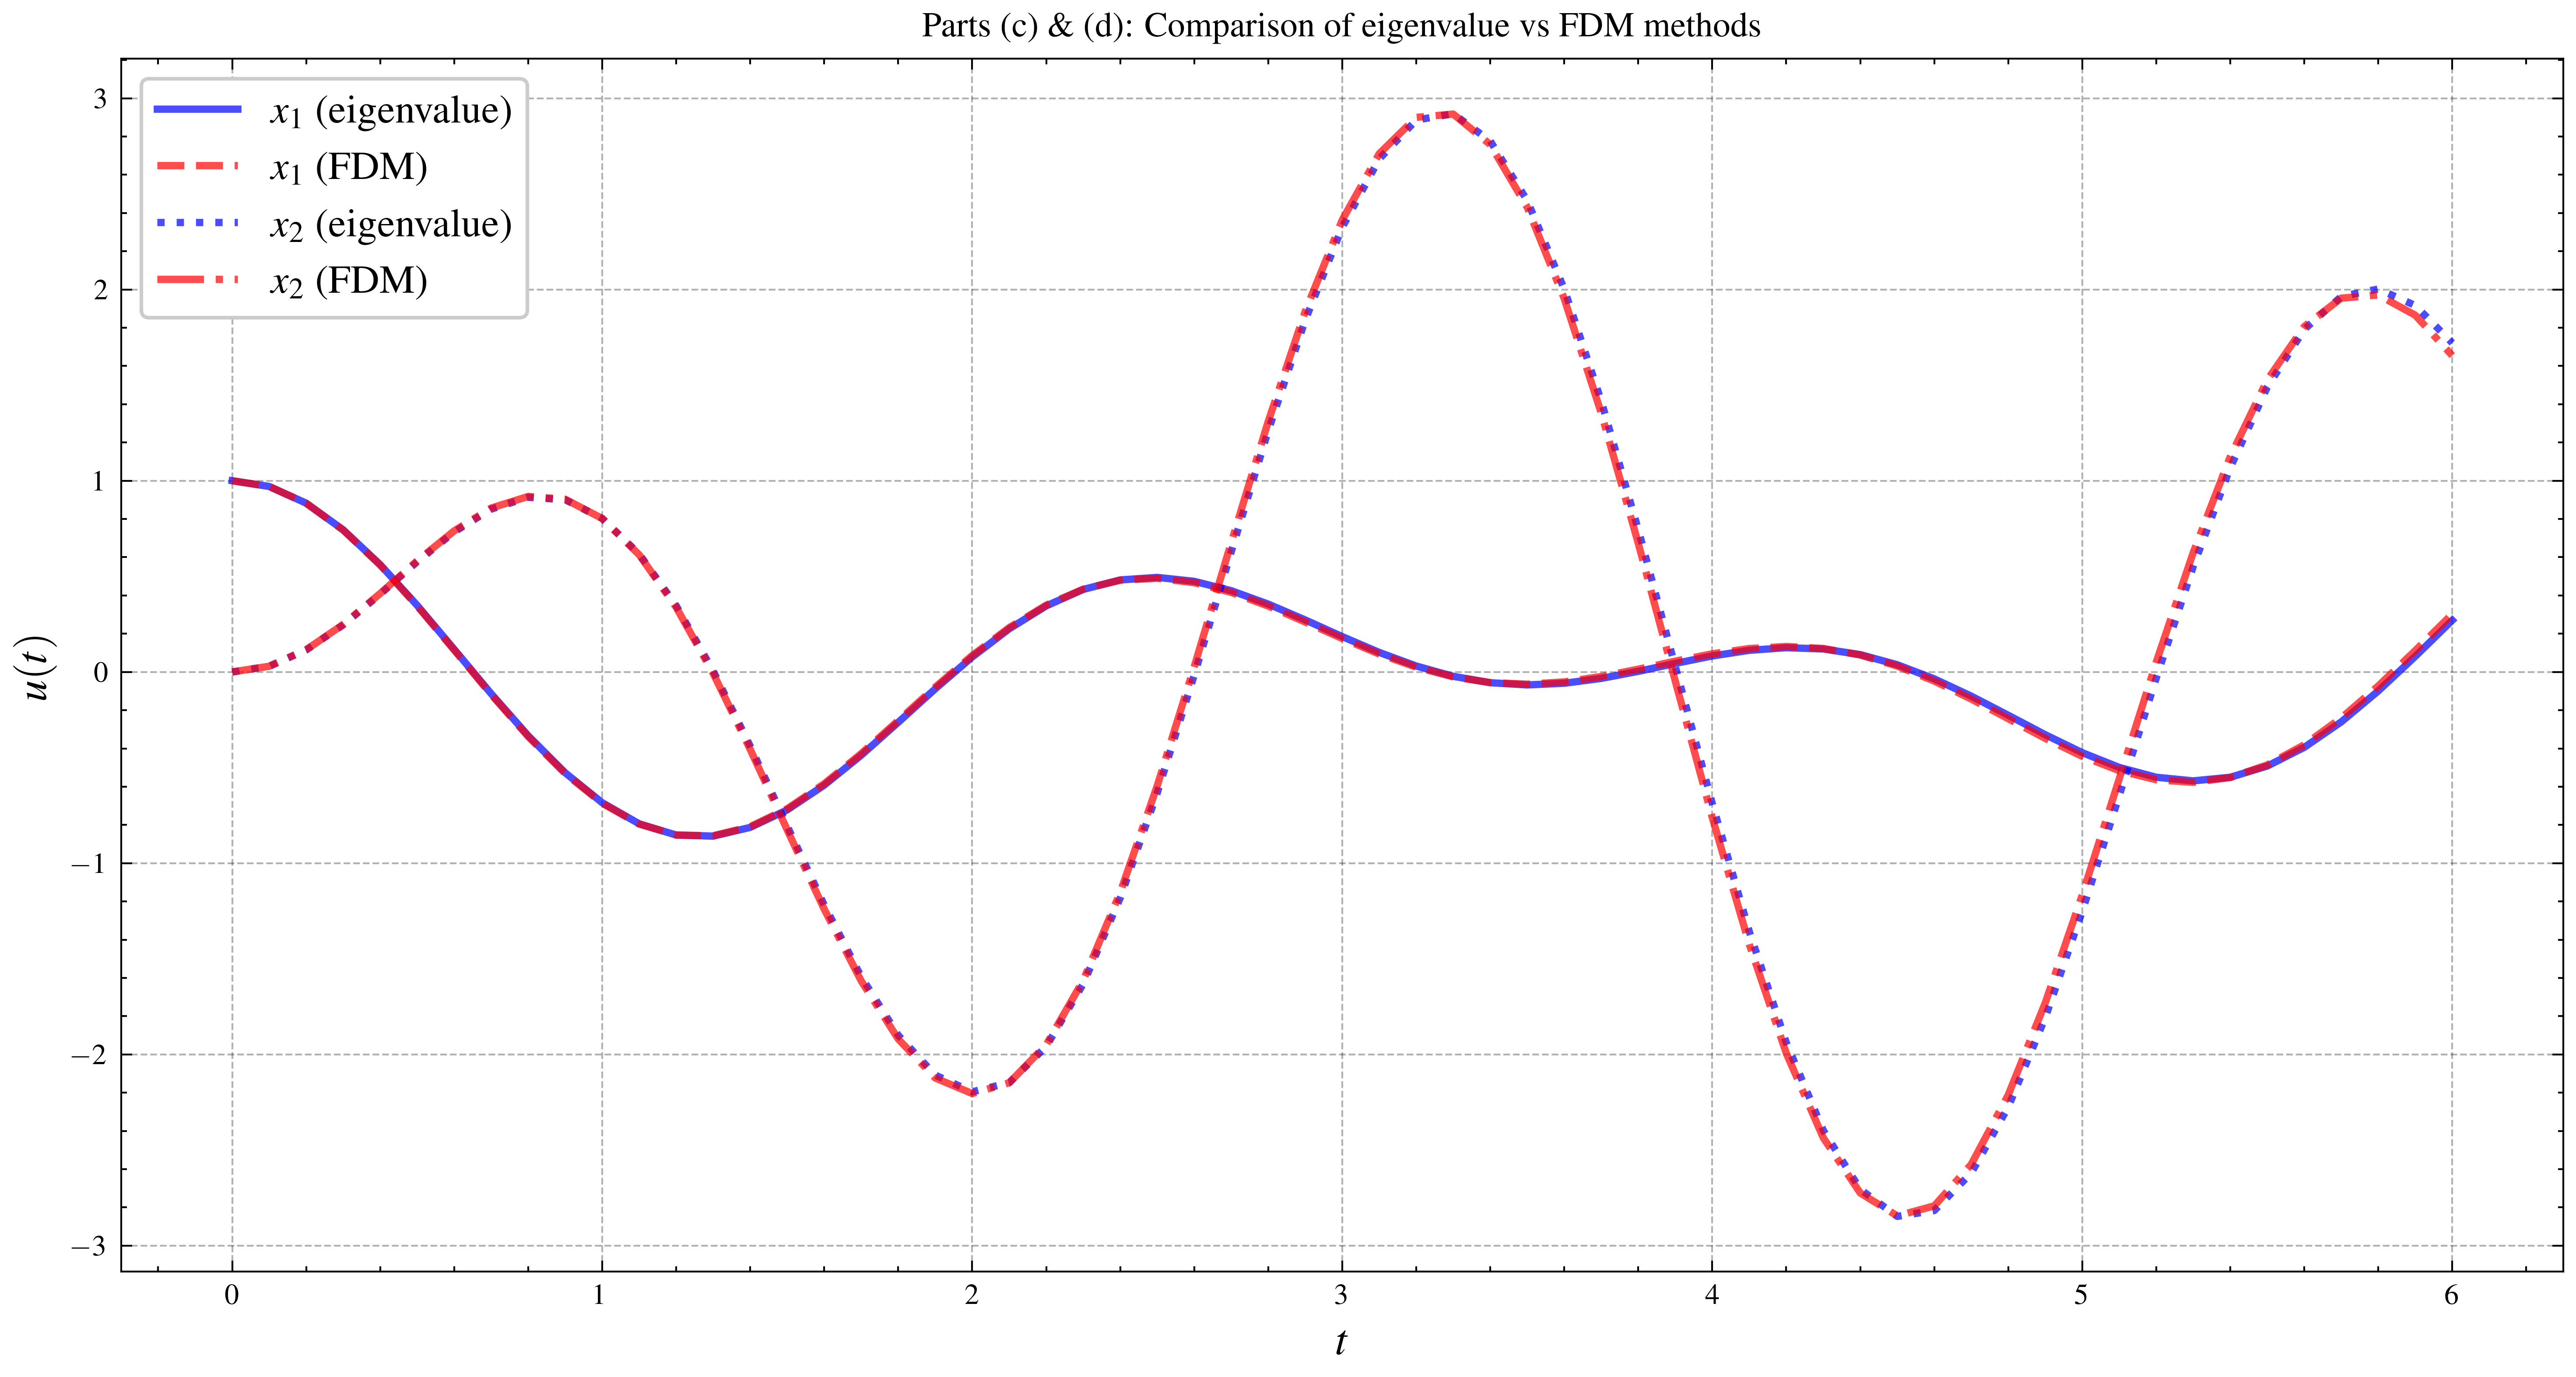


Part (c)-(d) Analysis:
  max|eig-ivp|: x1=9.266e-10, x2=2.848e-09
  max|fdm-ivp|: x1=3.273e-02, x2=8.734e-02

Discussion:
  (i) Accuracy: FDM error O(0.1^2)=O(0.01); eigenvalue has ~machine precision
  (ii) Stability: Δt=0.1 is stable (within Courant limit ~0.24 for ω_max~8.2)
  (iii) Eigenvalue method: exact for linear systems but limited to small n
       FDM method: generalizes to nonlinear systems, suitable for large-scale problems


In [3]:
def system_matrices():
    m1, m2 = 3.0, 1.0 / 3.0
    c1, c2 = 16.0, 2.0
    M = np.diag([m1, m2])
    K = np.array([[c1 + c2, -c2], [-c2, c2]], dtype=float)
    return M, K


def eig_method(t, u0=None, v0=None):
    if u0 is None:
        u0 = np.array([1.0, 0.0])
    if v0 is None:
        v0 = np.array([0.0, 0.0])

    M, K = system_matrices()
    A = np.linalg.solve(M, K)
    lam, Phi = np.linalg.eig(A)
    idx = np.argsort(lam)
    lam = lam[idx]
    Phi = Phi[:, idx]
    omega = np.sqrt(lam)

    a = np.linalg.solve(Phi, u0)
    b = np.linalg.solve(Phi, v0) / omega

    U = np.zeros((len(t), 2))
    for k, tk in enumerate(t):
        q = a * np.cos(omega * tk) + b * np.sin(omega * tk)
        U[k, :] = (Phi @ q).real
    return U


def fdm_method(t, u0=None, v0=None):
    if u0 is None:
        u0 = np.array([1.0, 0.0])
    if v0 is None:
        v0 = np.array([0.0, 0.0])

    dt = t[1] - t[0]
    n = len(t)
    M, K = system_matrices()
    MinvK = np.linalg.solve(M, K)

    U = np.zeros((n, 2))
    U[0, :] = u0
    U[1, :] = u0 + dt * v0 - 0.5 * dt * dt * (MinvK @ u0)

    for k in range(1, n - 1):
        U[k + 1, :] = 2 * U[k, :] - U[k - 1, :] - dt * dt * (MinvK @ U[k, :])
    return U


def ivp_method(t, u0=None, v0=None):
    if u0 is None:
        u0 = np.array([1.0, 0.0])
    if v0 is None:
        v0 = np.array([0.0, 0.0])

    M, K = system_matrices()

    def rhs(_, y):
        u = y[:2]
        v = y[2:]
        a = -np.linalg.solve(M, K @ u)
        return np.hstack((v, a))

    y0 = np.hstack((u0, v0))
    sol = solve_ivp(rhs, (t[0], t[-1]), y0, t_eval=t, rtol=1e-9, atol=1e-11)
    return sol.y[:2, :].T


t = np.arange(0.0, 6.0 + 1e-12, 0.1)
Ue = eig_method(t)
Uf = fdm_method(t)
Ui = ivp_method(t)

# Part (b): Animation of a serial vertical spring-mass system (m2 below m1)

plt.style.use(["science", "ieee", "grid"])
fig, ax = plt.subplots(figsize=(4, 8), dpi=96)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(0.0, 4.2)
ax.invert_yaxis()
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_ylabel("Vertical position (downward)")
ax.set_title("Part (b): Ceiling-spring-m1-spring-m2")

# Ceiling anchor and fixed horizontal line
x_anchor = 0.0
y_ceiling = 0.2
ax.plot([-0.9, 0.9], [y_ceiling, y_ceiling], "k-", lw=3)

# Visualization geometry
L1_eq = 1.2
L2_eq = 1.0
disp_scale = 0.25
min_gap = 0.35

y1 = y_ceiling + L1_eq + disp_scale * Ue[:, 0]
# Use relative motion (x2-x1) for the lower spring and enforce m2 stays below m1
rel_21 = Ue[:, 1] - Ue[:, 0]
y2_candidate = y1 + L2_eq + disp_scale * rel_21
y2 = np.maximum(y2_candidate, y1 + min_gap)


def spring_curve(x0, y0, y1_val, turns=10, amp=0.08):
    ys = np.linspace(y0, y1_val, 2 * turns + 1)
    xs = np.full_like(ys, x0)
    xs[1:-1:2] += amp
    xs[2:-1:2] -= amp
    xs[0] = x0
    xs[-1] = x0
    return xs, ys


(spring_top,) = ax.plot([], [], color="tab:blue", lw=2)
(spring_low,) = ax.plot([], [], color="tab:orange", lw=2)
(mass1,) = ax.plot([], [], "o", color="tab:blue", markersize=8, label="$m_1$")
(mass2,) = ax.plot([], [], "o", color="tab:orange", markersize=4, label="$m_2$")
time_text = ax.text(-1.05, 4.35, "", fontsize=11)
disp_text = ax.text(-1.05, 4.55, "", fontsize=11)
ax.legend(loc="upper right")


def init():
    spring_top.set_data([], [])
    spring_low.set_data([], [])
    mass1.set_data([], [])
    mass2.set_data([], [])
    time_text.set_text("")
    disp_text.set_text("")
    return spring_top, spring_low, mass1, mass2, time_text, disp_text


def update(k):
    xs1, ys1 = spring_curve(x_anchor, y_ceiling, y1[k])
    xs2, ys2 = spring_curve(x_anchor, y1[k], y2[k])
    spring_top.set_data(xs1, ys1)
    spring_low.set_data(xs2, ys2)
    mass1.set_data([x_anchor], [y1[k]])
    mass2.set_data([x_anchor], [y2[k]])
    time_text.set_text(f"t = {t[k]:.2f} s")
    disp_text.set_text(f"x1 = {Ue[k, 0]:+.3f}, x2 = {Ue[k, 1]:+.3f} (displacement)")
    return spring_top, spring_low, mass1, mass2, time_text, disp_text


anim = FuncAnimation(
    fig, update, frames=len(t), init_func=init, interval=80, blit=True
).save("../out/spring_mass_animation.gif", writer="pillow", fps=24)
plt.close(fig)

# Part (c) & (d): Comparison
plt.style.use(["science", "ieee", "grid"])
_, ax = plt.subplots(figsize=(12, 6))
ax.plot(t, Ue[:, 0], "b-", linewidth=2, label="$x_1$ (eigenvalue)", alpha=0.7)
ax.plot(t, Uf[:, 0], "r--", linewidth=2, label="$x_1$ (FDM)", alpha=0.7)
ax.plot(t, Ue[:, 1], "b:", linewidth=2, label="$x_2$ (eigenvalue)", alpha=0.7)
ax.plot(t, Uf[:, 1], "r-.", linewidth=2, label="$x_2$ (FDM)", alpha=0.7)
ax.set_xlabel("$t$", fontsize=12)
ax.set_ylabel("$u(t)$", fontsize=12)
ax.set_title("Parts (c) \\& (d): Comparison of eigenvalue vs FDM methods")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.show()

# Error analysis
err_fdm_vs_ivp = np.max(np.abs(Uf - Ui), axis=0)
err_eig_vs_ivp = np.max(np.abs(Ue - Ui), axis=0)
print("\nPart (c)-(d) Analysis:")
print(f"  max|eig-ivp|: x1={err_eig_vs_ivp[0]:.3e}, x2={err_eig_vs_ivp[1]:.3e}")
print(f"  max|fdm-ivp|: x1={err_fdm_vs_ivp[0]:.3e}, x2={err_fdm_vs_ivp[1]:.3e}")
print("\nDiscussion:")
print("  (i) Accuracy: FDM error O(0.1^2)=O(0.01); eigenvalue has ~machine precision")
print("  (ii) Stability: Δt=0.1 is stable (within Courant limit ~0.24 for ω_max~8.2)")
print("  (iii) Eigenvalue method: exact for linear systems but limited to small n")
print(
    "       FDM method: generalizes to nonlinear systems, suitable for large-scale problems"
)

![](../out/spring_mass_animation.gif)

### Problem 3: Epidemics

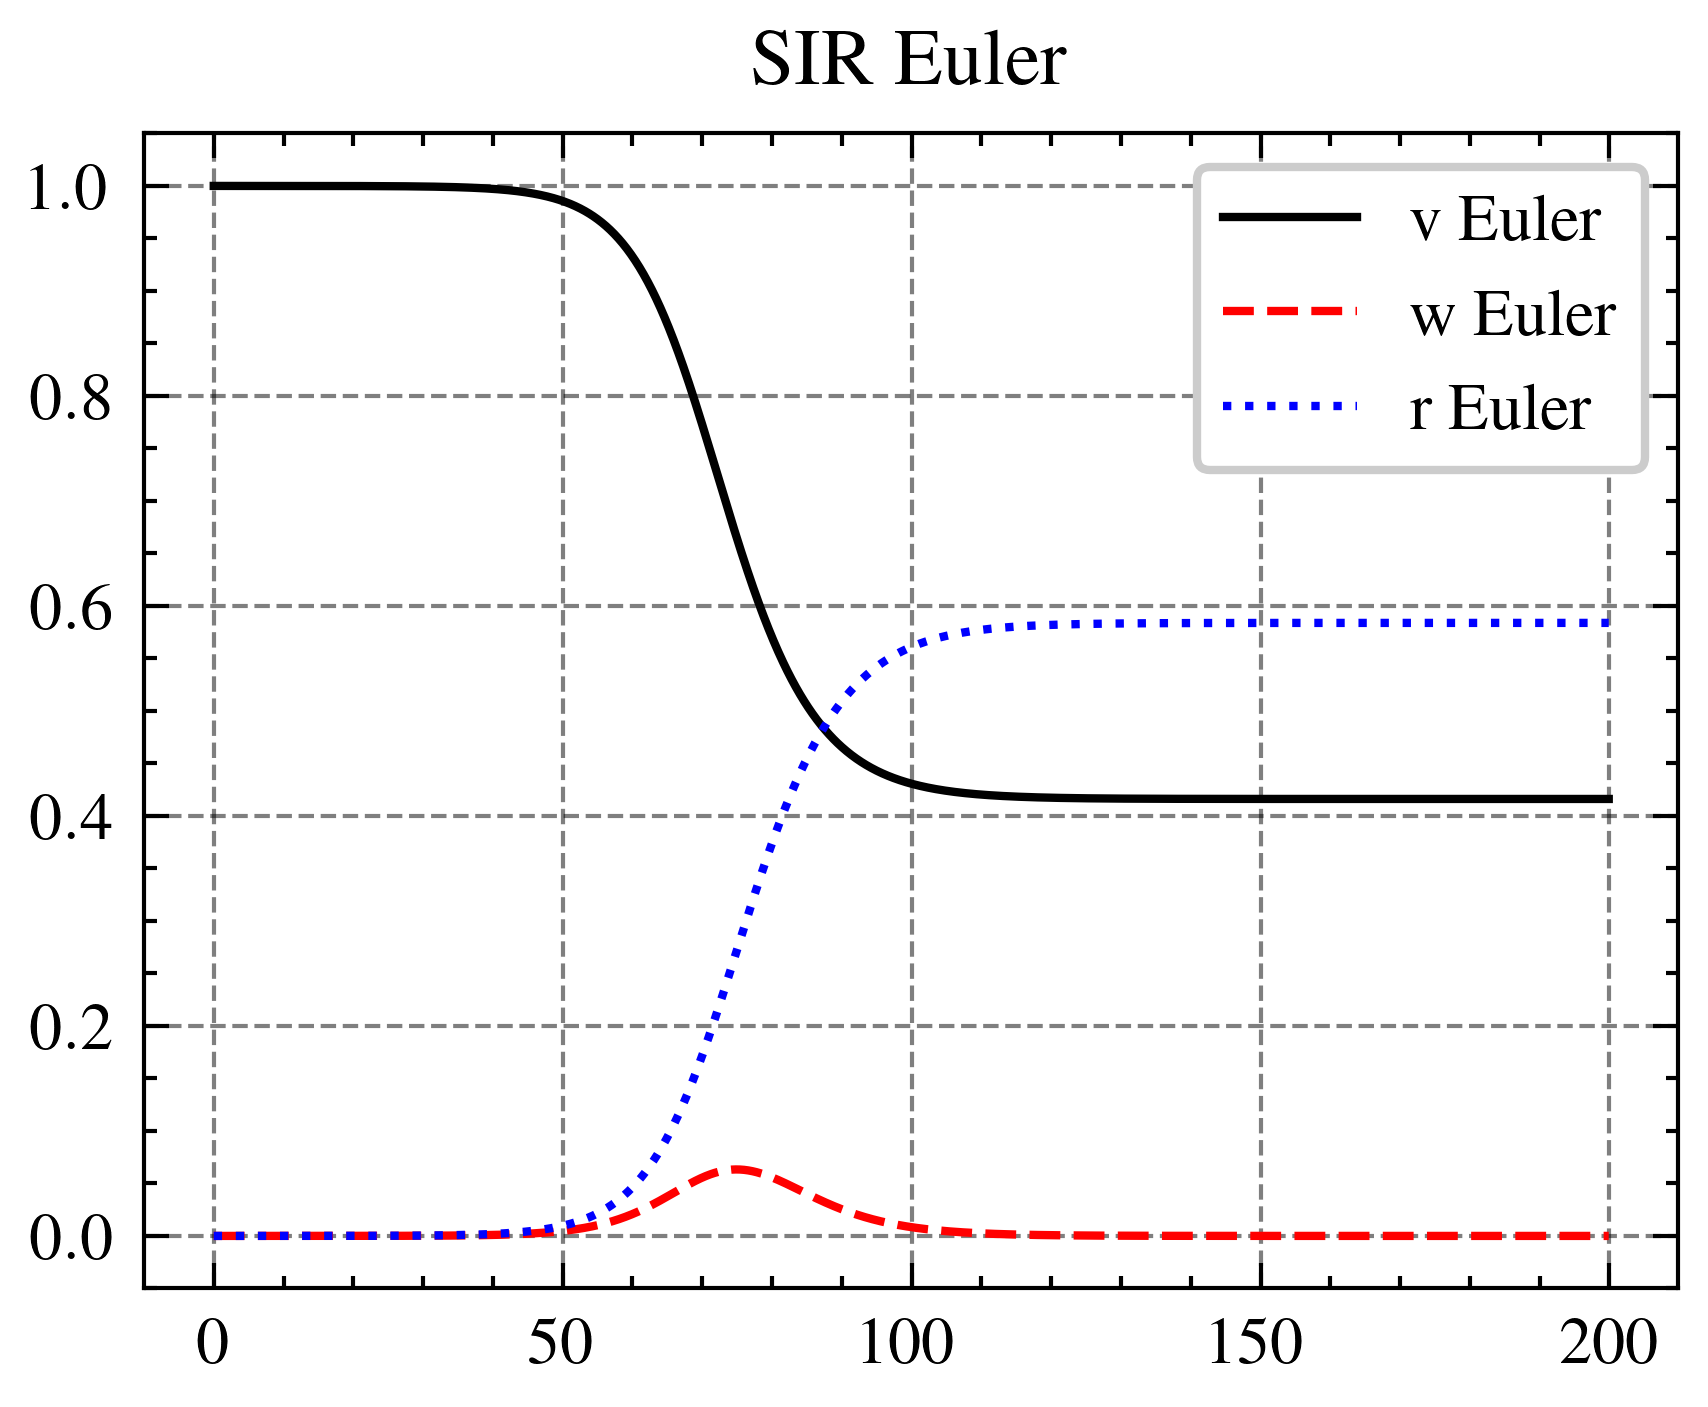

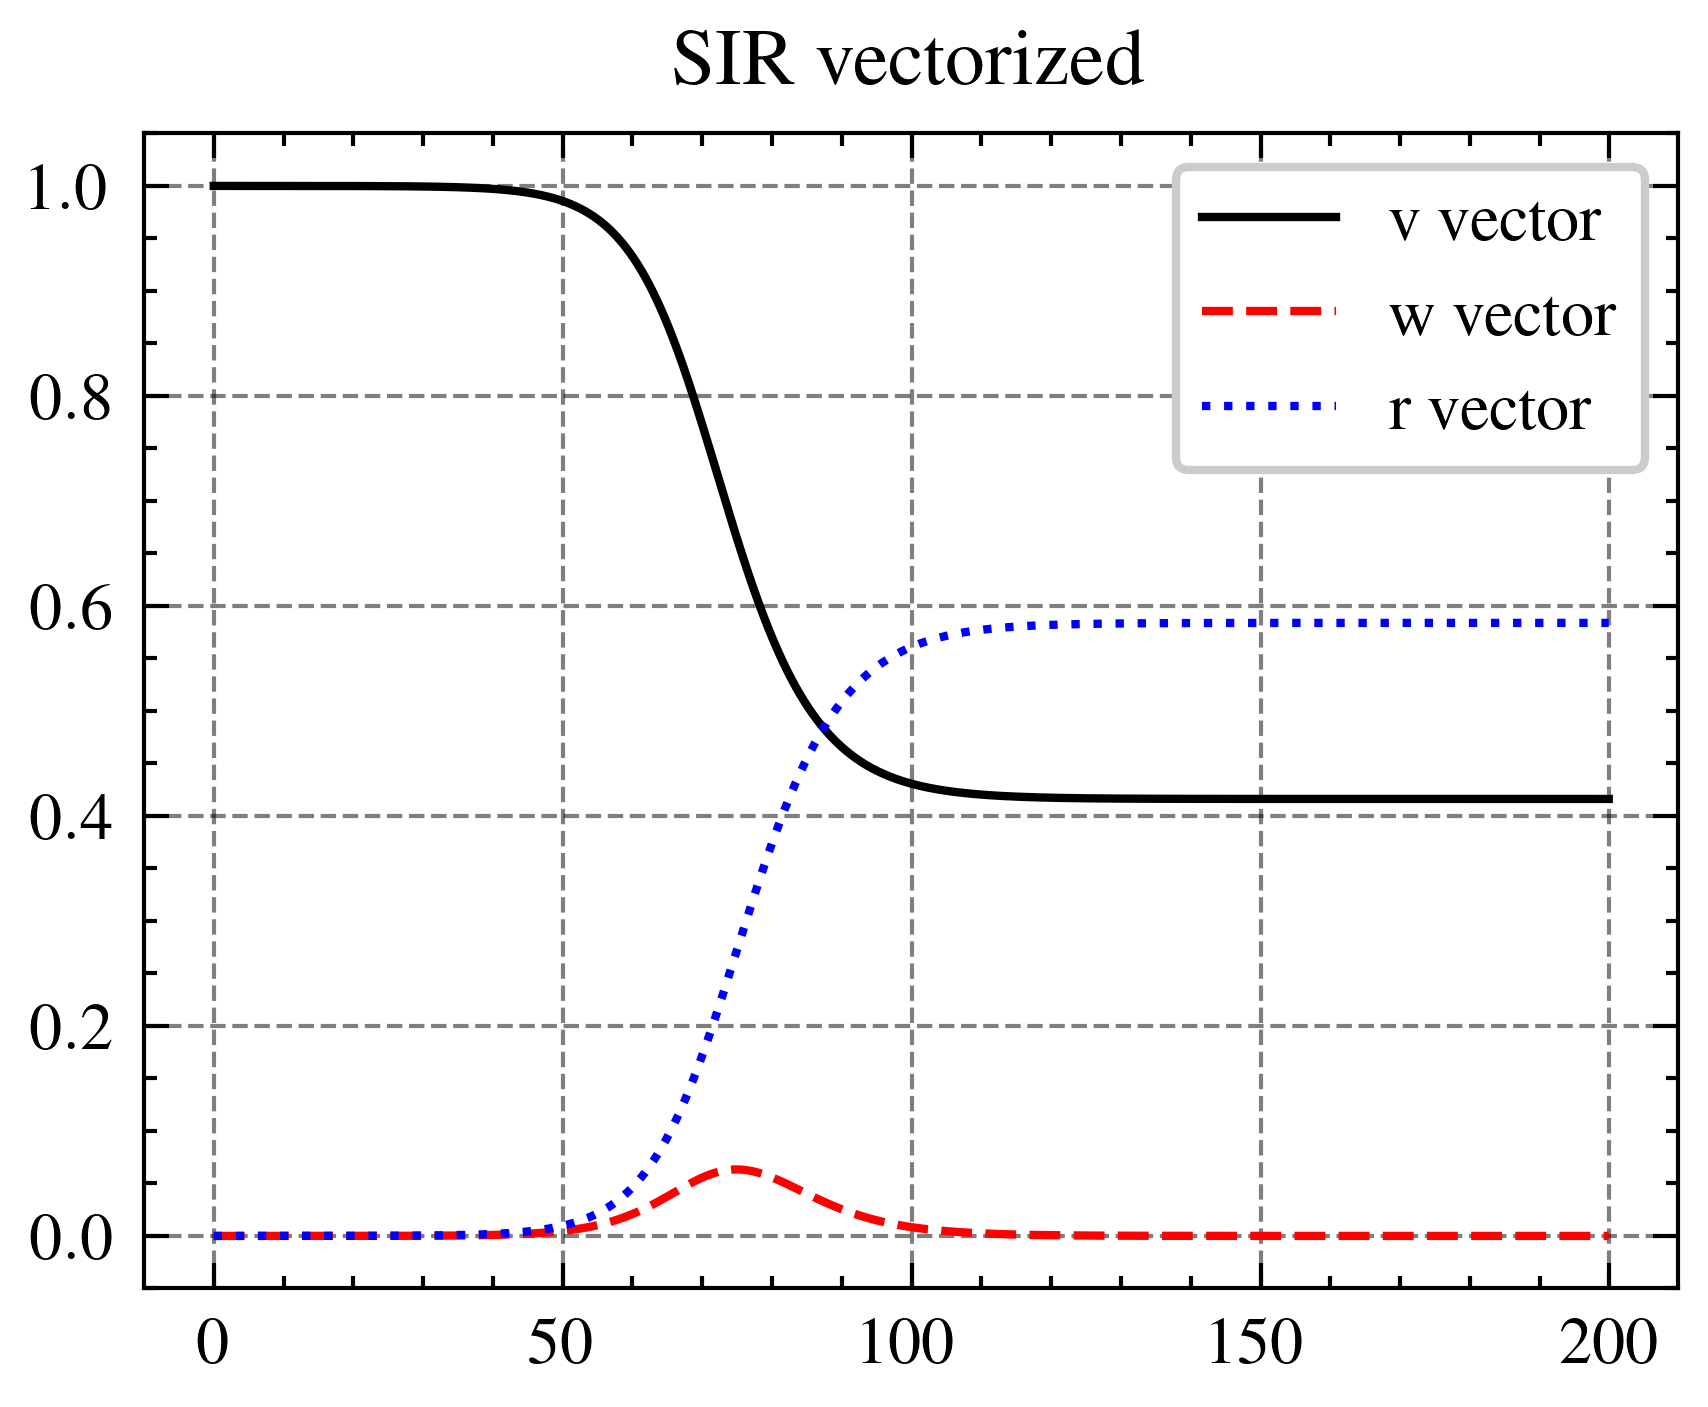

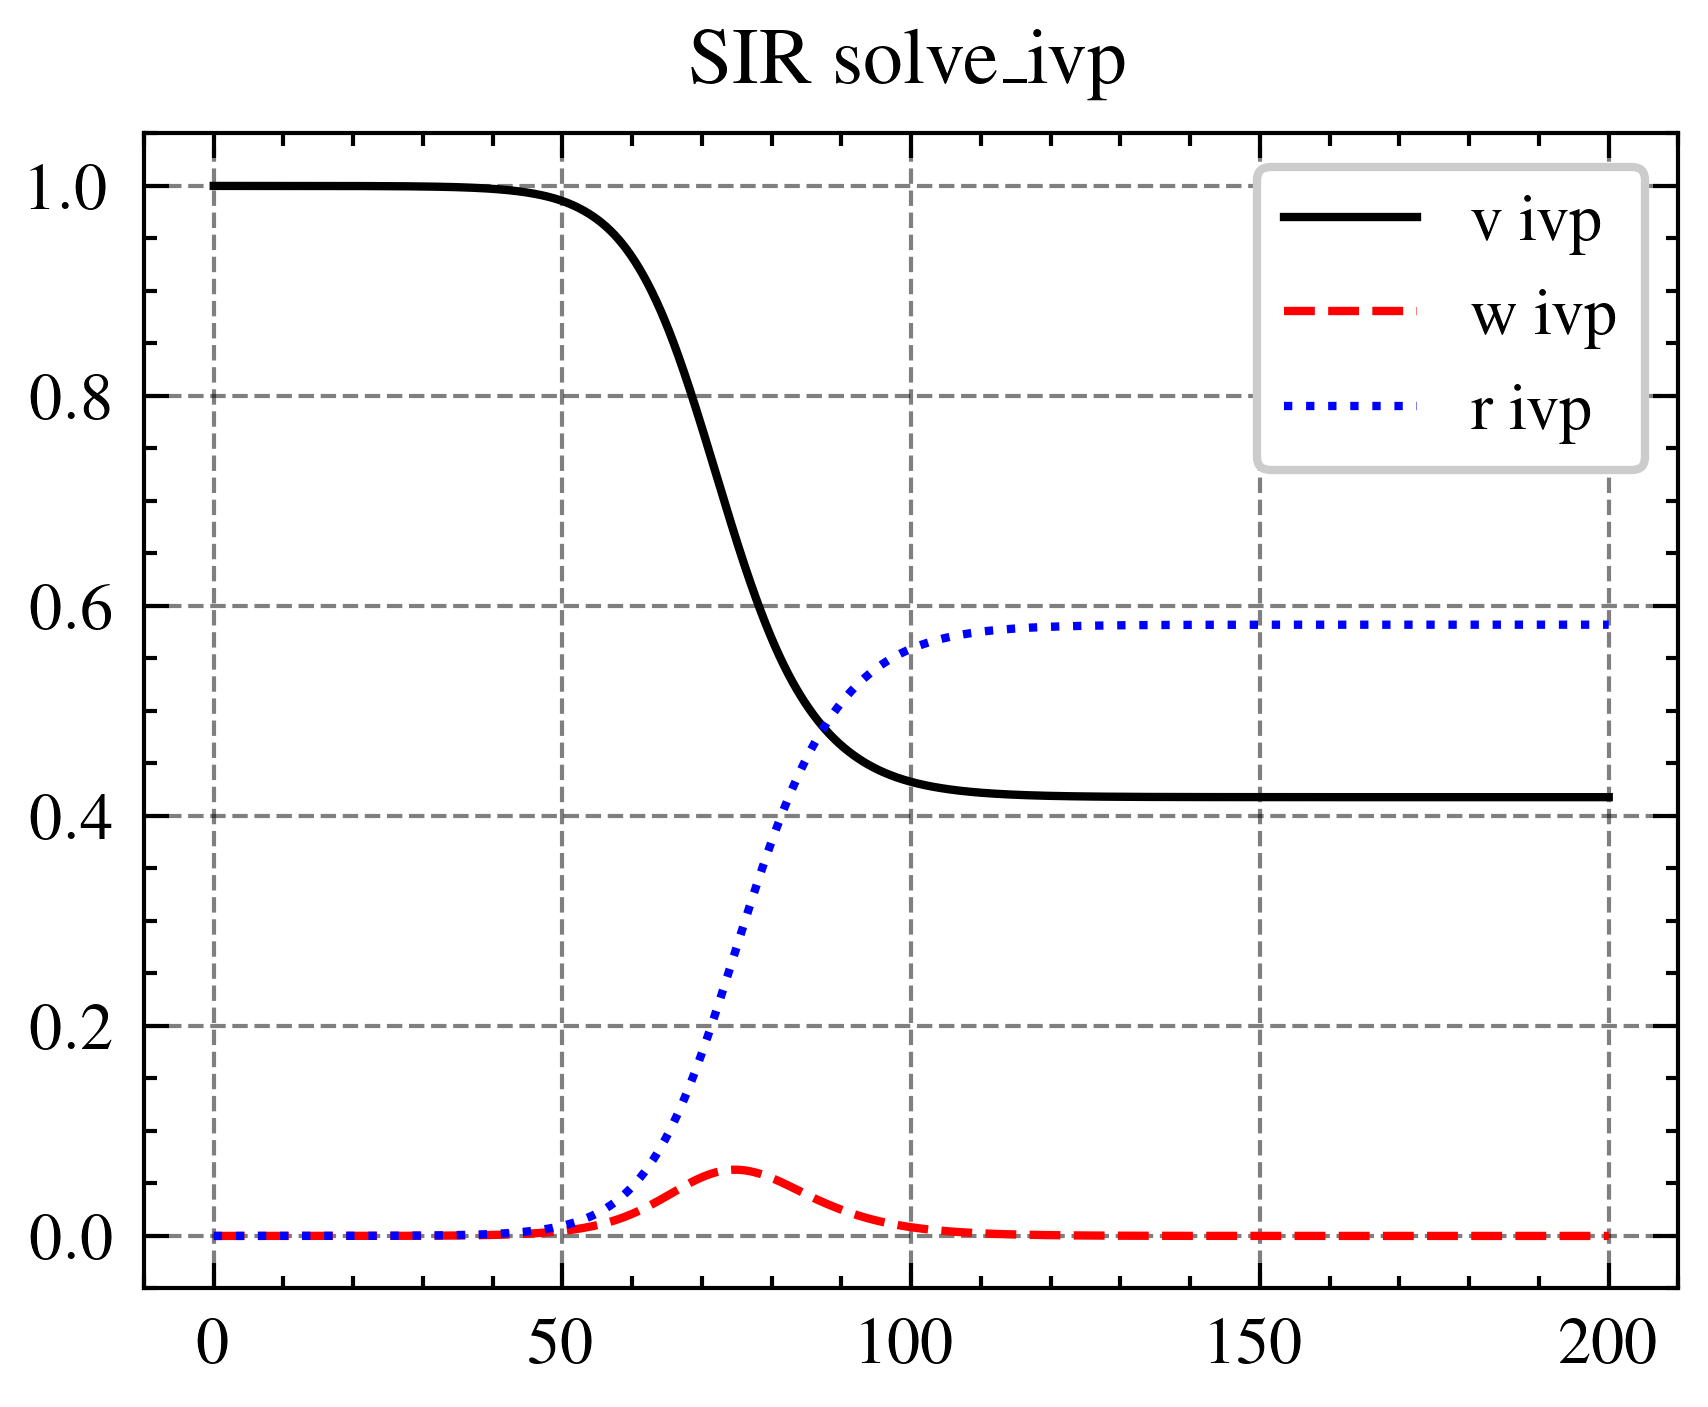

In [4]:
def option_euler(a, b, v0, w0, r0, Nt=1000, dt=0.001):
    t = np.arange(Nt) * dt
    v = np.zeros(Nt)
    w = np.zeros(Nt)
    r = np.zeros(Nt)
    v[0], w[0], r[0] = v0, w0, r0
    for i in range(1, Nt):
        v[i] = v[i - 1] + dt * (-a * v[i - 1] * w[i - 1])
        w[i] = w[i - 1] + dt * (a * v[i - 1] * w[i - 1] - b * w[i - 1])
        r[i] = r[i - 1] + dt * (b * w[i - 1])
    return t, v, w, r


def option_vectorized(a, b, v0, w0, r0, Nt=1000, dt=0.001):
    t = np.arange(Nt) * dt
    v = np.empty(Nt)
    w = np.empty(Nt)
    r = np.empty(Nt)
    v[0], w[0], r[0] = v0, w0, r0
    for i in range(1, Nt):
        # same as Euler but written compactly
        dv = -a * v[i - 1] * w[i - 1]
        dw = a * v[i - 1] * w[i - 1] - b * w[i - 1]
        dr = b * w[i - 1]
        v[i] = v[i - 1] + dt * dv
        w[i] = w[i - 1] + dt * dw
        r[i] = r[i - 1] + dt * dr
    return t, v, w, r


def option_ivp(a, b, v0, w0, r0, T=100, Nt=1000):
    def rhs(t, y):
        v, w, r = y
        return [-a * v * w, a * v * w - b * w, b * w]

    t_span = (0, T)
    t_eval = np.linspace(0, T, Nt)
    sol = solve_ivp(rhs, t_span, [v0, w0, r0], t_eval=t_eval)
    return sol.t, sol.y


a = 1.0 / 2
b = 1.0 / 3
v0 = 1.0
w0 = 1.27e-6
r0 = 0.0
t1, v1, w1, r1 = option_euler(a, b, v0, w0, r0, Nt=2000, dt=0.1)
t2, v2, w2, r2 = option_vectorized(a, b, v0, w0, r0, Nt=2000, dt=0.1)
t3, Y3 = option_ivp(a, b, v0, w0, r0, T=200, Nt=2000)

plt.style.use(["science", "ieee", "grid"])
plt.figure()
plt.plot(t1, v1, label="v Euler")
plt.plot(t1, w1, label="w Euler")
plt.plot(t1, r1, label="r Euler")
plt.legend()
plt.title("SIR Euler")
plt.show()

plt.figure()
plt.plot(t2, v2, label="v vector")
plt.plot(t2, w2, label="w vector")
plt.plot(t2, r2, label="r vector")
plt.legend()
plt.title("SIR vectorized")
plt.show()

plt.figure()
plt.plot(t3, Y3[0, :], label="v ivp")
plt.plot(t3, Y3[1, :], label="w ivp")
plt.plot(t3, Y3[2, :], label="r ivp")
plt.legend()
plt.title("SIR solve_ivp")
plt.show()

### Problem 4: Accuracy of ODE solvers

Final time T = 0.0002
     n  method                rel-L2 error    time (s)     steps
--------------------------------------------------------------------------------------
   201  Forward Euler           1.1121e-01      0.0000         5
   201  Runge-Kutta4            1.7484e-03      0.0002         5
   201  Backward Euler          7.1625e-02      0.0004         5
   201  Trapezoidal             5.9557e-03      0.0004         5
   201  BDF2                    2.4140e-02      0.0006         5
   201  Reference expm          0.0000e+00      0.0013     adapt
   201  ode45 (RK45)            2.4433e-07      0.0031     adapt
   201  ode15s (BDF)            1.0444e-06      0.0279     adapt
--------------------------------------------------------------------------------------
  2001  Forward Euler           7.1835e-04      0.0059       446
  2001  Backward Euler          7.1850e-04      0.0191       446
  2001  BDF2                    1.1461e-06      0.0223       446
  2001  Trapezoidal     

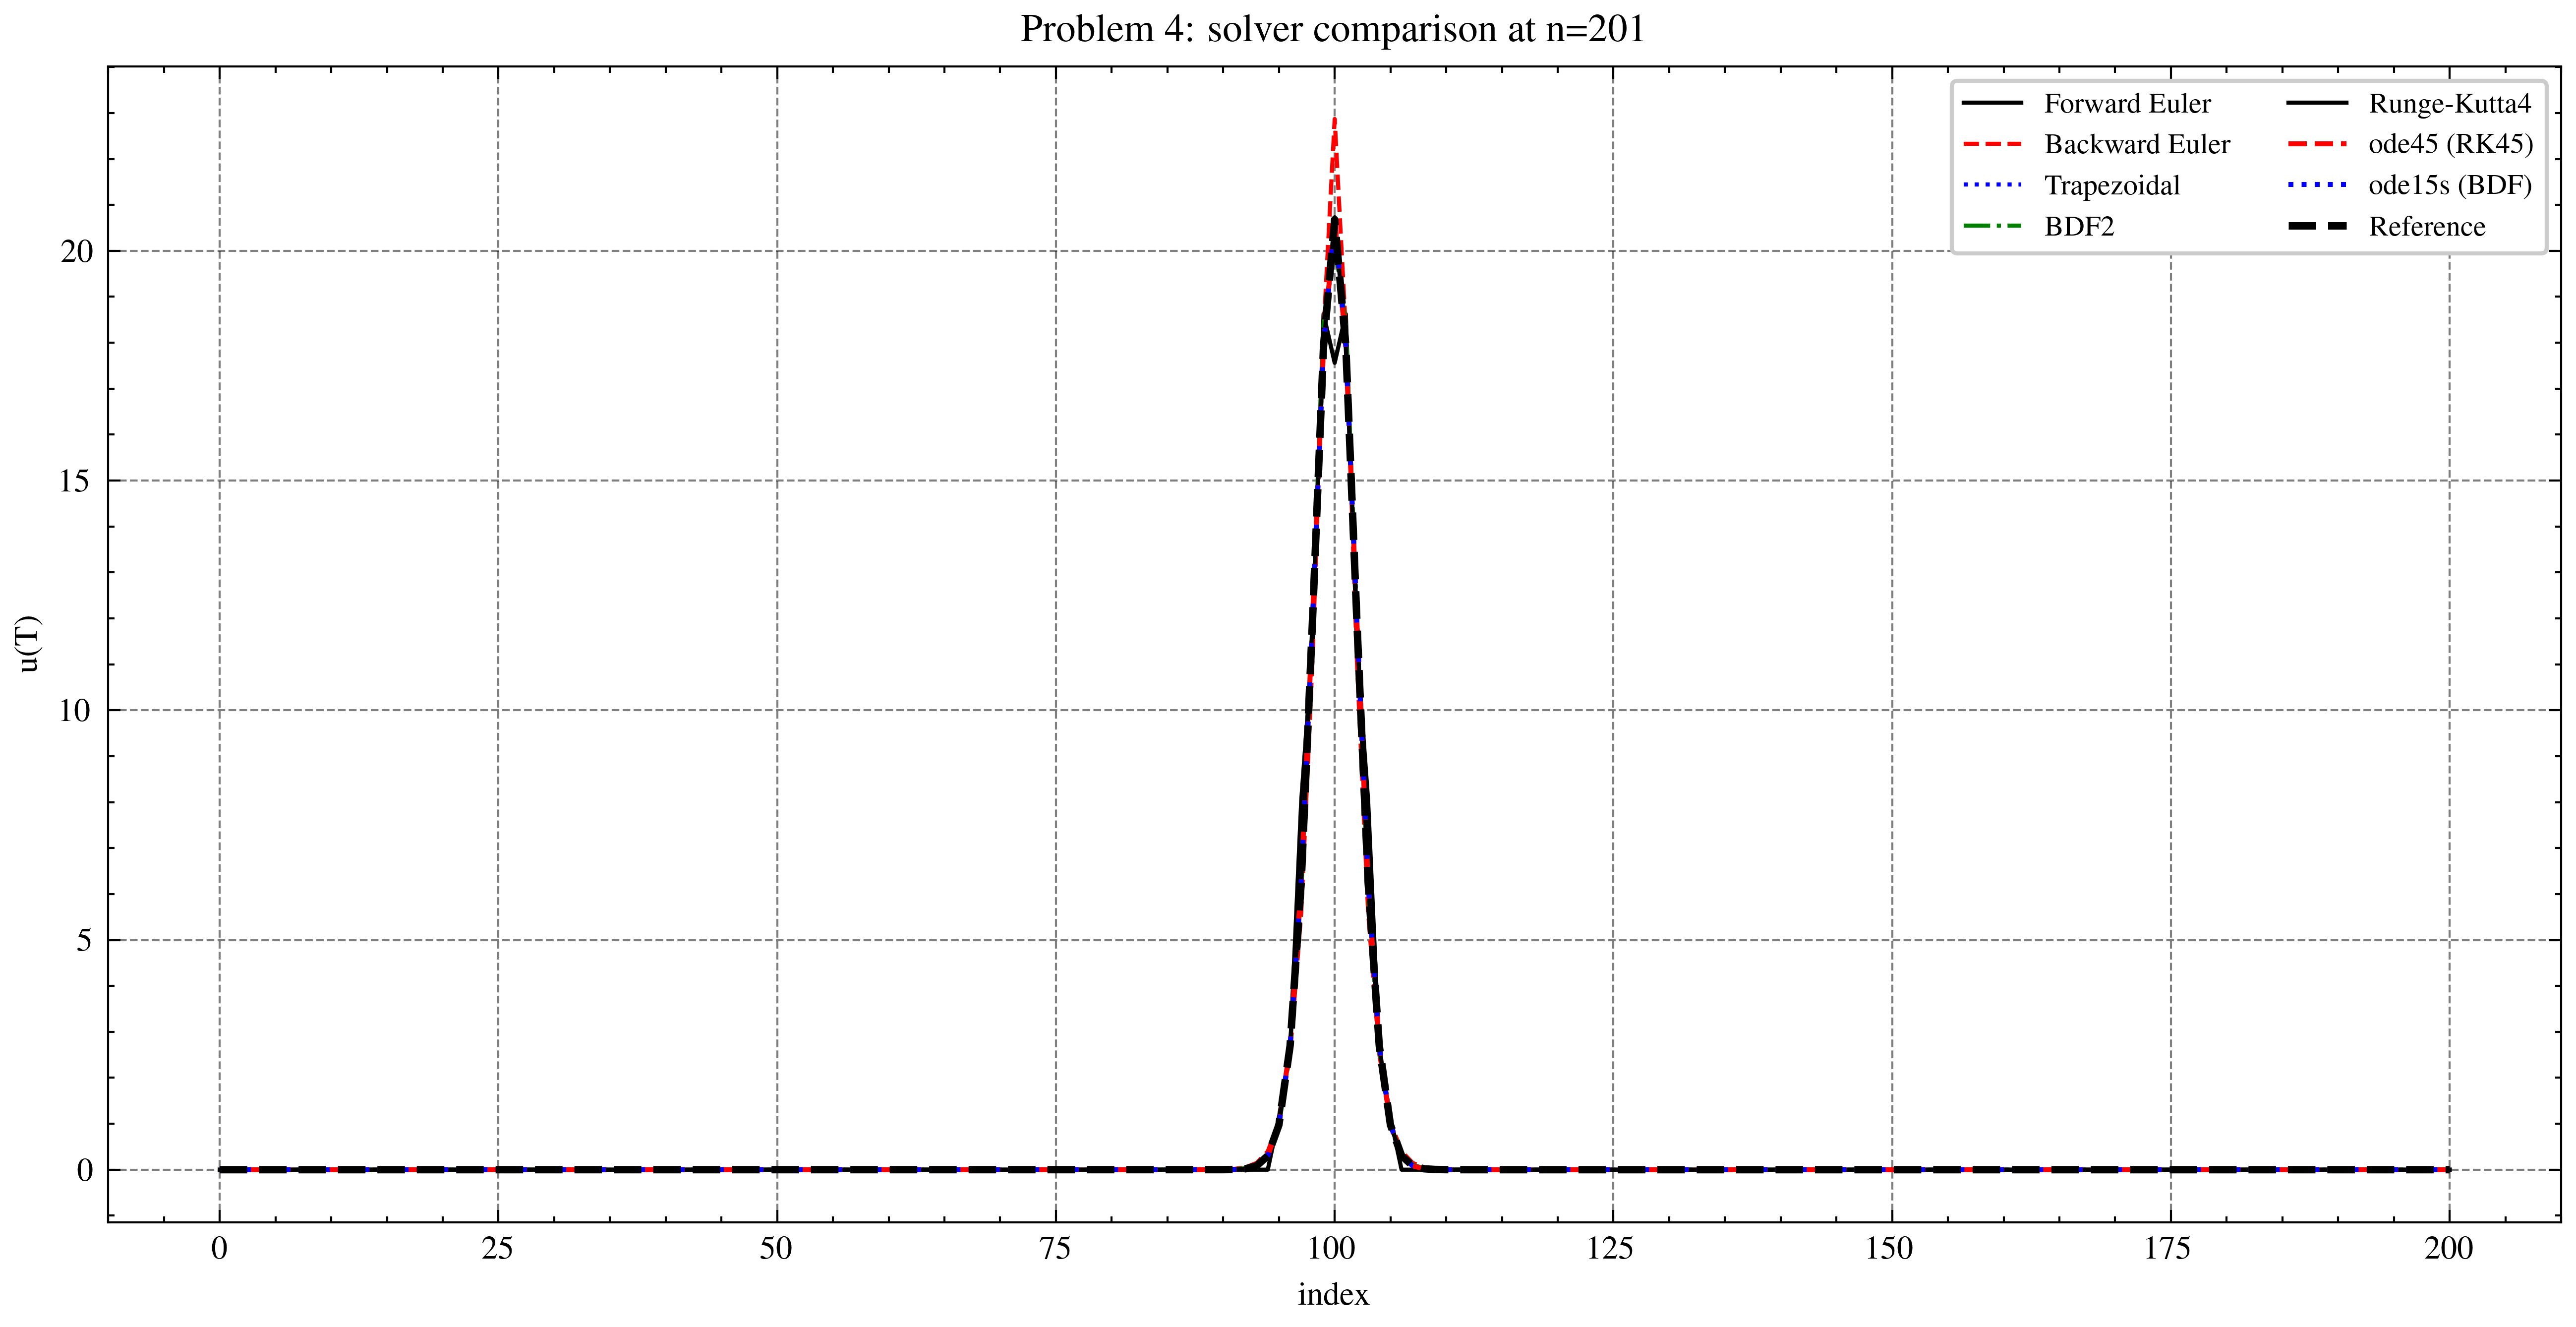

In [5]:
def build_problem(n):
    """Build A = K/h^2 and delta-like initial condition."""
    N = (n - 1) // 2
    h = 1.0 / (N + 1)

    main = -2.0 * np.ones(n)
    off = 1.0 * np.ones(n - 1)
    K = sparse.diags([off, main, off], offsets=[-1, 0, 1], format="csc")
    A = K / (h * h)

    u0 = np.zeros(n)
    u0[N] = 1.0 / h
    return h, A, u0


def forward_euler(A, u0, dt, n_steps):
    u = u0.copy()
    for _ in range(n_steps):
        u = u + dt * (A @ u)
    return u


def rk4(A, u0, dt, n_steps):
    u = u0.copy()
    for _ in range(n_steps):
        k1 = A @ u
        k2 = A @ (u + 0.5 * dt * k1)
        k3 = A @ (u + 0.5 * dt * k2)
        k4 = A @ (u + dt * k3)
        u = u + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
    return u


def backward_euler(A, u0, dt, n_steps):
    n = u0.size
    II = sparse.identity(n, format="csc")
    solver = splu((II - dt * A).tocsc())

    u = u0.copy()
    for _ in range(n_steps):
        u = solver.solve(u)
    return u


def trapezoidal(A, u0, dt, n_steps):
    n = u0.size
    II = sparse.identity(n, format="csc")
    L = (II - 0.5 * dt * A).tocsc()
    R = (II + 0.5 * dt * A).tocsc()
    solver = splu(L)

    u = u0.copy()
    for _ in range(n_steps):
        u = solver.solve(R @ u)
    return u


def bdf2(A, u0, dt, n_steps):
    """BDF2 with one BE start-up step."""
    if n_steps == 0:
        return u0.copy()

    n = u0.size
    II = sparse.identity(n, format="csc")

    # Step 1 by backward Euler
    be_solver = splu((II - dt * A).tocsc())
    u_prev = u0.copy()
    u_curr = be_solver.solve(u_prev)

    if n_steps == 1:
        return u_curr

    # BDF2: (3u_{k+1} - 4u_k + u_{k-1})/(2dt) = A u_{k+1}
    bdf2_solver = splu(((1.5) * II - dt * A).tocsc())

    for _ in range(1, n_steps):
        rhs = 2.0 * u_curr - 0.5 * u_prev
        u_next = bdf2_solver.solve(rhs)
        u_prev, u_curr = u_curr, u_next

    return u_curr


def solve_ivp_method(A, u0, T, method):
    def rhs(_, y):
        return A @ y

    sol = solve_ivp(
        rhs,
        (0.0, T),
        u0,
        method=method,
        rtol=1e-6,
        atol=1e-9,
        t_eval=[T],
    )
    return sol.y[:, -1]


def rel_l2_error(u, u_ref):
    denom = np.linalg.norm(u_ref)
    if denom == 0.0:
        return np.linalg.norm(u - u_ref)
    return np.linalg.norm(u - u_ref) / denom


# Test settings
T = 2.0e-4
n_list = [201, 2001]
method_names = [
    "Forward Euler",
    "Backward Euler",
    "Trapezoidal",
    "BDF2",
    "Runge-Kutta4",
    "ode45 (RK45)",
    "ode15s (BDF)",
]

all_results = []
profile_plot_data = {}

for n in n_list:
    h, A, u0 = build_problem(n)

    # Reference: exact semigroup action u(T)=exp(TA)u0
    t0 = time.perf_counter()
    u_ref = expm_multiply(T * A, u0)
    t_ref = time.perf_counter() - t0

    # Explicit-step-size tied to h^2 for stability
    dt = 0.45 * h * h
    n_steps = int(np.ceil(T / dt))
    dt = T / n_steps

    run_pack = [
        ("Forward Euler", lambda: forward_euler(A, u0, dt, n_steps), n_steps),
        ("Backward Euler", lambda: backward_euler(A, u0, dt, n_steps), n_steps),
        ("Trapezoidal", lambda: trapezoidal(A, u0, dt, n_steps), n_steps),
        ("BDF2", lambda: bdf2(A, u0, dt, n_steps), n_steps),
        ("Runge-Kutta4", lambda: rk4(A, u0, dt, n_steps), n_steps),
        ("ode45 (RK45)", lambda: solve_ivp_method(A, u0, T, "RK45"), np.nan),
        ("ode15s (BDF)", lambda: solve_ivp_method(A, u0, T, "BDF"), np.nan),
    ]

    for name, solver, steps in run_pack:
        t0 = time.perf_counter()
        u_num = solver()
        elapsed = time.perf_counter() - t0
        err = rel_l2_error(u_num, u_ref)
        all_results.append((n, name, err, elapsed, steps))

        if n == 201:
            profile_plot_data[name] = u_num.copy()

    all_results.append((n, "Reference expm", 0.0, t_ref, np.nan))
    if n == 201:
        profile_plot_data["Reference expm"] = u_ref.copy()


# Print result table
print(f"Final time T = {T:g}")
print("=" * 86)
print(f"{'n':>6}  {'method':<18}  {'rel-L2 error':>14}  {'time (s)':>10}  {'steps':>8}")
print("-" * 86)
for n in n_list:
    rows = [r for r in all_results if r[0] == n]
    rows = sorted(rows, key=lambda x: (x[3], x[2]))
    for rn, name, err, elapsed, steps in rows:
        step_txt = f"{int(steps)}" if np.isfinite(steps) else "adapt"
        print(f"{rn:6d}  {name:<18}  {err:14.4e}  {elapsed:10.4f}  {step_txt:>8}")
    print("-" * 86)


# Plot for n=201
plt.style.use(["science", "ieee", "grid"])
plt.figure(figsize=(8.8, 4.6))
idx = np.arange(201)
for name in method_names:
    u = profile_plot_data[name]
    if "ode" in name:
        plt.plot(idx, u, linewidth=1.2, label=name)
    else:
        plt.plot(idx, u, linewidth=1.0, label=name)

plt.plot(
    idx, profile_plot_data["Reference expm"], "k--", linewidth=1.8, label="Reference"
)
plt.xlabel("index")
plt.ylabel("u(T)")
plt.title("Problem 4: solver comparison at n=201")
plt.legend(ncol=2, fontsize=7)
plt.tight_layout()
plt.show()

Scan done: n=201, total runs=100
Pareto points (sorted by time):
method                   T     cfl   steps   rel-L2 error    time(s)
------------------------------------------------------------------------------------------
Forward Euler      1.0e-04    0.60       2     1.0224e+00    0.00002
Forward Euler      1.0e-04    0.45       3     1.3030e-01    0.00003
Forward Euler      2.0e-04    0.45       5     1.1121e-01    0.00004
Forward Euler      1.0e-04    0.25       5     7.5755e-02    0.00004
Forward Euler      2.0e-04    0.35       6     5.6411e-02    0.00004
Forward Euler      1.0e-04    0.15       7     5.5133e-02    0.00006
Forward Euler      2.0e-04    0.25       9     3.7926e-02    0.00006
Forward Euler      4.0e-04    0.45      10     3.4057e-02    0.00007
Forward Euler      4.0e-04    0.35      12     2.7418e-02    0.00008
Forward Euler      2.0e-04    0.15      14     2.4528e-02    0.00010
Runge-Kutta4       1.0e-04    0.45       3     7.4638e-03    0.00010
Runge-Kutta4    

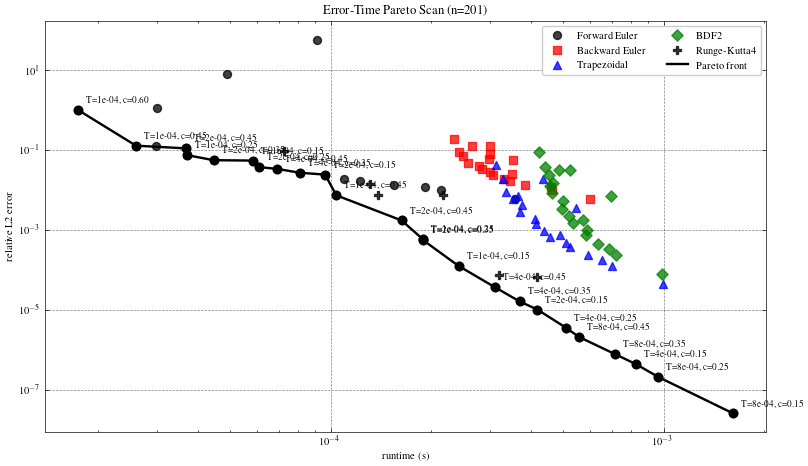

In [6]:
# Problem 4 extension: scan T and step sizes, then plot error-time Pareto front

import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import expm_multiply


def pareto_front_indices(errors, times_):
    """Return indices on Pareto front for minimizing (error, time)."""
    n = len(errors)
    is_pareto = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_pareto[i]:
            continue
        dominated = (
            (errors <= errors[i])
            & (times_ <= times_[i])
            & ((errors < errors[i]) | (times_ < times_[i]))
        )
        if np.any(dominated):
            is_pareto[i] = False
    return np.where(is_pareto)[0]


# Scan setup
n_scan = 201
T_list = [1e-4, 2e-4, 4e-4, 8e-4]
cfl_list = [0.15, 0.25, 0.35, 0.45, 0.60]
methods = {
    "Forward Euler": forward_euler,
    "Backward Euler": backward_euler,
    "Trapezoidal": trapezoidal,
    "BDF2": bdf2,
    "Runge-Kutta4": rk4,
}

h, A_scan, u0_scan = build_problem(n_scan)
scan_results = []

for T_scan in T_list:
    u_ref_scan = expm_multiply(T_scan * A_scan, u0_scan)

    for cfl in cfl_list:
        dt_try = cfl * h * h
        n_steps_scan = int(np.ceil(T_scan / dt_try))
        dt_scan = T_scan / n_steps_scan

        for method_name, solver in methods.items():
            t0 = time.perf_counter()
            u_num_scan = solver(A_scan, u0_scan, dt_scan, n_steps_scan)
            elapsed_scan = time.perf_counter() - t0
            err_scan = rel_l2_error(u_num_scan, u_ref_scan)

            scan_results.append(
                {
                    "method": method_name,
                    "T": T_scan,
                    "cfl": cfl,
                    "dt": dt_scan,
                    "steps": n_steps_scan,
                    "error": err_scan,
                    "time": elapsed_scan,
                }
            )


# Convert to arrays for Pareto processing
all_errors = np.array([r["error"] for r in scan_results])
all_times = np.array([r["time"] for r in scan_results])
pareto_idx = pareto_front_indices(all_errors, all_times)

# Sort Pareto points for plotting/printing
pareto_idx = pareto_idx[np.argsort(all_times[pareto_idx])]

print(f"Scan done: n={n_scan}, total runs={len(scan_results)}")
print("Pareto points (sorted by time):")
print("=" * 90)
print(
    f"{'method':<16} {'T':>9} {'cfl':>7} {'steps':>7} {'rel-L2 error':>14} {'time(s)':>10}"
)
print("-" * 90)
for i in pareto_idx:
    r = scan_results[int(i)]
    print(
        f"{r['method']:<16} {r['T']:9.1e} {r['cfl']:7.2f} {r['steps']:7d} "
        f"{r['error']:14.4e} {r['time']:10.5f}"
    )
print("=" * 90)


# Plot error-time cloud + Pareto front
plt.style.use(["science", "ieee", "grid"])
plt.figure(figsize=(8.6, 5.0), dpi=96)

method_order = list(methods.keys())
markers = ["o", "s", "^", "D", "P"]

for mk, method_name in zip(markers, method_order):
    method_pts = [r for r in scan_results if r["method"] == method_name]
    x = [r["time"] for r in method_pts]
    y = [r["error"] for r in method_pts]
    plt.scatter(x, y, s=36, marker=mk, alpha=0.75, label=method_name)

pareto_x = all_times[pareto_idx]
pareto_y = all_errors[pareto_idx]
plt.plot(pareto_x, pareto_y, "k-", linewidth=1.8, label="Pareto front")
plt.scatter(pareto_x, pareto_y, c="k", s=42, zorder=5)

for i in pareto_idx:
    r = scan_results[int(i)]
    label = f"T={r['T']:.0e}, c={r['cfl']:.2f}"
    plt.annotate(
        label,
        (r["time"], r["error"]),
        textcoords="offset points",
        xytext=(6, 5),
        fontsize=7,
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("runtime (s)")
plt.ylabel("relative L2 error")
plt.title(f"Error-Time Pareto Scan (n={n_scan})")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()